# 99 — Atlas map

Static choropleth of the livability score, plus an interactive re-weighting widget to see how weight changes shift the map.

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

from common import PROCESSED_DIR, load_layers, load_weights, normalize, weighted_score

## Load

In [22]:
score = xr.open_dataarray(PROCESSED_DIR / 'score.nc')

## Static map

Text(0.5, 1.0, 'World livability atlas')

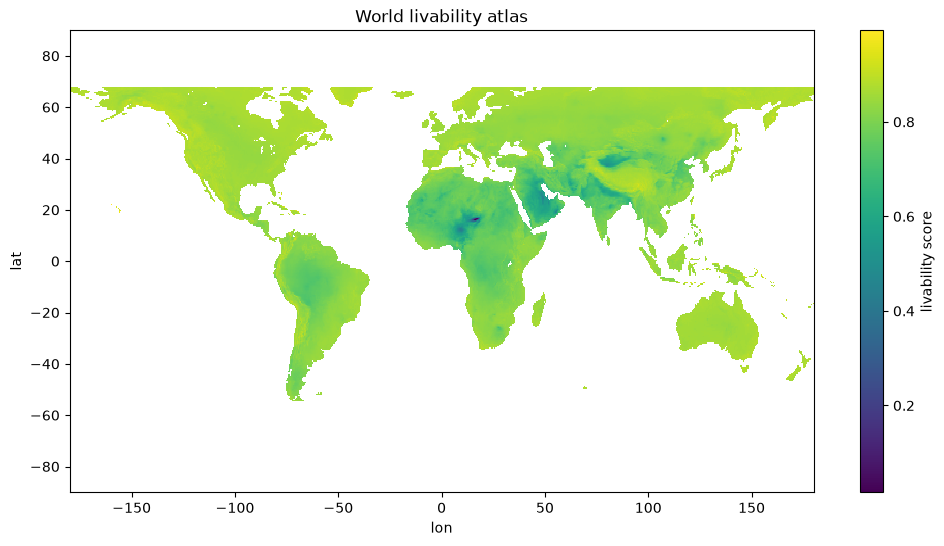

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
score.plot(ax=ax, cmap='viridis', cbar_kwargs={'label': 'livability score'})
ax.set_title('World livability atlas')

## Interactive re-weighting

Sliders per variable rebuild the score on the fly. Uses raw (un-normalized) weights so the slider values match `weights.yaml`.

In [ ]:
import ipywidgets as widgets

raw_weights = load_weights()
layers = {name: normalize(da) for name, da in load_layers(raw_weights).items()}

sliders = {
    name: widgets.FloatSlider(value=raw_weights[name], min=0, max=2, step=0.1, description=name[:15])
    for name in layers
}

def redraw(**kw):
    active = {k: w for k, w in kw.items() if w > 0}
    fig, ax = plt.subplots(figsize=(12, 6))
    if active:
        weighted_score({k: layers[k] for k in active}, active).plot(ax=ax, cmap='viridis')
    plt.show()

widgets.interact(redraw, **sliders)